### Handwritten Digits Recognition using Neural Network

##### 1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### 2. Importing Dataset

In [2]:
!wget https://raw.githubusercontent.com/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/14-Handwritten%20Dfigits%20Recognition/Train.csv

--2026-03-02 17:50:13--  https://raw.githubusercontent.com/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/14-Handwritten%20Dfigits%20Recognition/Train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 76775041 (73M) [text/plain]
Saving to: ‘Train.csv’

Train.csv           100%[===================>]  73.22M   267MB/s    in 0.3s    

2026-03-02 17:50:14 (267 MB/s) - ‘Train.csv’ saved [76775041/76775041]



In [3]:
df = pd.read_csv('Train.csv')
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

##### 3. Preprocess the Data

In [11]:
# Feature Preprocessing
X = X.apply(pd.to_numeric, errors = 'coerce')
X = X.fillna(0)
X = X.values/255.0
X = X.reshape(-1, 28, 28, 1)
X.shape

(42000, 28, 28, 1)

In [12]:
# Target Preprocessing
# One Hot Encoding
from tensorflow.keras.utils import to_categorical
y = to_categorical(y, num_classes=10)
y.shape

(42000, 10)

##### 4. Train and Test Split

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##### 5. Building the Model

In [20]:
import tensorflow as tf
model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Input(shape=(28, 28, 1)))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))

model.compile(
    loss = tf.keras.losses.categorical_crossentropy,
    optimizer = tf.keras.optimizers.Adam(),
    metrics = ['accuracy']
)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

##### 6. Fit the Model

In [22]:
history = model.fit(X_train, y_train,
          epochs = 10,
          batch_size = 32,
          validation_data = (X_test, y_test)
          )

Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9955 - loss: 0.0152 - val_accuracy: 0.9736 - val_loss: 0.1223
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9964 - loss: 0.0110 - val_accuracy: 0.9724 - val_loss: 0.1334
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9965 - loss: 0.0108 - val_accuracy: 0.9729 - val_loss: 0.1261
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9960 - loss: 0.0132 - val_accuracy: 0.9690 - val_loss: 0.1567
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9955 - loss: 0.0130 - val_accuracy: 0.9719 - val_loss: 0.1406
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9975 - loss: 0.0084 - val_accuracy: 0.9695 - val_loss: 0.1672
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9961 - loss: 0.0100 - val_accuracy: 0.9725 - val_loss: 0.1563
Epoch 8/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9968 - loss: 0.0102 - 

##### 7. Model Evaluation

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9678 - loss: 0.2044
Validation Accuracy: 96.86%


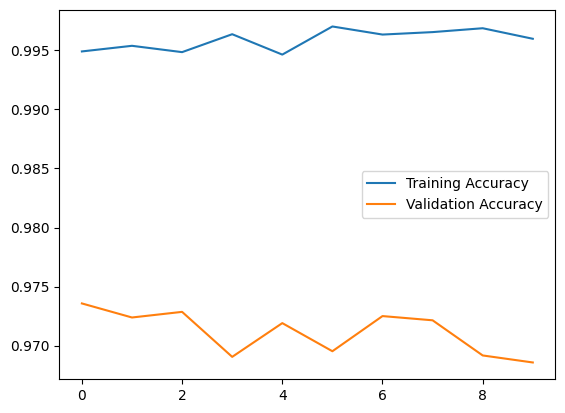

In [23]:
val_loss, val_accuracy = model.evaluate(X_test, y_test)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

##### 8. Make Prediction

In [30]:
prediction = model.predict([X_test])
np.argmax(prediction[0]), np.argmax(y_test[0])

263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


(np.int64(8), np.int64(8))

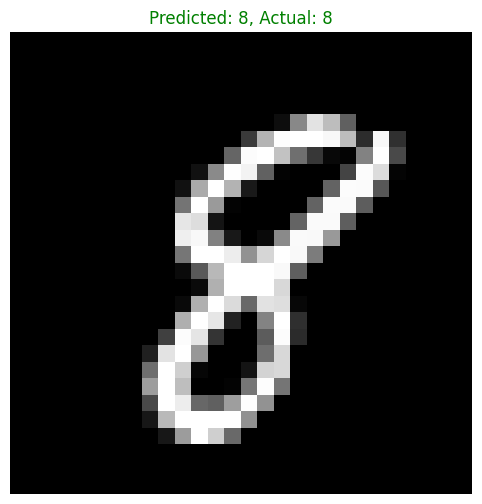

In [51]:
index = 4
predict_num = np.argmax(prediction[index])
actual_num = np.argmax(y_test[index])
color = 'g' if predict_num == actual_num else 'r'
plt.figure(figsize=(10, 6))
plt.imshow(X_test[index].reshape(28, 28), cmap='gray')
plt.title(f'Predicted: {predict_num}, Actual: {actual_num}', color= color)
plt.axis('off')
plt.show()